# <span style="color: darkblue;"> 📓 Projet final : Smart Fuel – Estimation et Optimisation du prix des carburants </span> 

##  <span style="color: darkblue;"> 📓 A). Smart Fuel – EDA & Data Cleaning </span>

#### <span style="color: darkblue;">🔹 1) Import des modules </span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix
import statsmodels.api as sm

#### <span style="color: darkblue;"> 🔹 2) Chargement des données </span>

In [2]:
data = pd.read_csv("prix-carburants-quotidien.csv", sep =";")

In [3]:
# Aperçu
data.head()

,id,Code postal,pop,adresse,ville,horaires,rupture,fermeture,geom,Mise à jour des prix,...,Numéro Département,Département,Code Officiel EPCI,Nom Officiel EPCI,Commune / Arrondissement Municipal,Services proposés,Carburant en rupture,Début rupture,Fin rupture,Automate 24-24 (oui/non)
0,15130001,15130,R,1 rue germain prat,LAFEUILLADE-EN-VéZIE,"{""@automate-24-24"": ""1"", ""jour"": [{""@id"": ""1"",...","{""@id"": ""4"", ""@nom"": ""GPLc"", ""@debut"": ""2017-0...",NaN,"44.788, 2.456",2026-04-18T23:31:23+00:00,...,15,Cantal,200066678.0,Communauté de communes de la Châtaigneraie Can...,Lafeuillade-en-Vézie,"Toilettes publiques,Boutique non alimentaire,S...",GPLc,2017-09-07T16:41:43+00:00,NaN,Oui
1,15190003,15190,R,route du Cezallier,Marcenat,"{""@automate-24-24"": ""1"", ""jour"": [{""@id"": ""1"",...","{""@id"": ""4"", ""@nom"": ""GPLc"", ""@debut"": ""2020-1...",NaN,"45.303141500363, 2.8327425989774997",2026-04-13T14:41:05+00:00,...,15,Cantal,200066637.0,Communauté de communes Hautes Terres Communauté,Marcenat,"Laverie,Station de gonflage,Piste poids lourds...",GPLc,2020-12-09T09:37:57+00:00,NaN,Oui
2,15200004,15200,R,Avenue de la Gare,Mauriac,"{""@automate-24-24"": ""1"", ""jour"": [{""@id"": ""1"",...","{""@id"": ""4"", ""@nom"": ""GPLc"", ""@debut"": ""2018-1...",NaN,"45.222, 2.34",2026-04-17T13:26:51+00:00,...,15,Cantal,241500271.0,Communauté de communes du Pays de Mauriac,Mauriac,"Toilettes publiques,Laverie,Boutique alimentai...",GPLc,2018-11-27T10:27:04+00:00,NaN,Oui
3,15210001,15210,R,Avenue Roger BESSE,Ydes,"{""@automate-24-24"": ""1"", ""jour"": [{""@id"": ""1"",...","{""@id"": ""2"", ""@nom"": ""SP95"", ""@debut"": ""2020-0...",NaN,"45.34, 2.434",2026-04-18T08:34:34+00:00,...,15,Cantal,241501055.0,Communauté de communes Sumène - Artense,Ydes,"Toilettes publiques,Laverie,Relais colis,Bouti...",SP95,2020-05-13T13:22:01+00:00,NaN,Oui
4,15250006,15250,R,1 route de brive,Saint-Paul-des-Landes,NaN,"{""@id"": ""5"", ""@nom"": ""E10"", ""@debut"": ""2022-01...",NaN,"44.94448371, 2.31132819",2026-04-17T13:59:37+00:00,...,15,Cantal,241500230.0,Communauté d'agglomération du Bassin d'Aurillac,Saint-Paul-des-Landes,NaN,E10,2022-01-04T13:18:56+00:00,NaN,Non


#### <span style="color: darkblue;"> 🔹 3) Compréhension des données </span>

In [4]:
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73184 entries, 0 to 73183
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  73184 non-null  int64  
 1   Code postal                         73184 non-null  int64  
 2   pop                                 73184 non-null  object 
 3   adresse                             73184 non-null  object 
 4   ville                               73184 non-null  object 
 5   horaires                            62107 non-null  object 
 6   rupture                             70139 non-null  object 
 7   fermeture                           143 non-null    object 
 8   geom                                73177 non-null  object 
 9   Mise à jour des prix                71308 non-null  object 
 10  prix_id                             71308 non-null  float64
 11  Prix                                71308

,id,Code postal,prix_id,Prix,Code Officiel Région,Code Officiel EPCI
count,7.318400e+04,73184.000000,71308.000000,71308.000000,73134.000000,7.312600e+04
mean,4.882258e+07,48810.231540,3.477043,1.949931,55.524858,2.154145e+08
std,2.624214e+07,26237.799573,2.035424,0.427944,26.365258,2.127363e+07
min,1.000001e+06,1000.000000,1.000000,0.600000,11.000000,2.000002e+08
25%,2.737000e+07,27380.000000,1.000000,1.976000,28.000000,2.000548e+08
50%,4.930301e+07,49300.000000,3.000000,2.049000,53.000000,2.000700e+08
75%,7.121001e+07,71210.000000,5.000000,2.189000,76.000000,2.431006e+08
max,9.999900e+07,99999.000000,6.000000,2.890000,94.000000,2.495005e+08


Nos données **prix-carburants-quotidien.csv** de source <span style="color: blue;"> data.gouv.fr </span>  sont le prix des carburants arrêtées le **19 Avril 2026**.

Les données contiennent **73184 lignes** et **26 colonnes** 

les colonnes les plus importants sont : 

**<span style="color: blue;"> id </span> :** contient les identifiants des stations services

**<span style="color: blue;"> Code postal </span> :** le code postal des stations

**<span style="color: blue;"> adresse </span> :** l'adresse des stations 

**<span style="color: blue;"> ville </span> :** la ville des stations 

**<span style="color: blue;"> geom </span> :** contient la position géographique (Latitude et Longitude) des stations

**<span style="color: blue;">  Mise à jour des prix </span> :** colonne très importante dans notre analyse contient la date de mise à jour du prix des carburants.

**<span style="color: blue;"> Prix </span> :** le prix des carburants

**<span style="color: blue;"> Carburant </span> :** contient les différents types de carburant (Gazole, SP95,....)

**<span style="color: blue;"> Région </span> :** les régions de la france 

**<span style="color: blue;">  Département </span> :** contient les départements de la France.

Nous remarquons qu'il y' a des valeurs manquantes sur plusieurs colonnes (geom, Prix, Mise à jour, .....), nous le traiterons dans les prochaines étapes.

Notre tableau de statistique descriptive nous montre qu'il n'y a pas beaucoup de colonnes numériques, il nous montre quand même que le **<span style="color: blue;"> Prix minimum </span>** des carburants est de **<span style="color: blue;"> 0,60 euros </span>**, **<span style="color: blue;">le Prix moyen </span>** est de **1,94 euros** et **<span style="color: blue;"> le Prix maximal </span>** est de **2,89 euros** le **19 Avril 2026**

#### <span style="color: darkblue;"> 🔹 4) Nettoyage des données </span>

##### <span style="color: darkblue;"> 🧹 Gestion des dates </span>

In [5]:
# Création de la colonne date qui est égale à la date de mise à jour des prix
data["date"] = data["Mise à jour des prix"]

In [6]:
# Conversion des dates 
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["Début rupture"] = pd.to_datetime(data["Début rupture"], errors="coerce")
data["Fin rupture"] = pd.to_datetime(data["Fin rupture"], errors="coerce")

##### <span style="color: darkblue;"> 🧹 Gestion des valeurs manquantes </span>

In [7]:
data.isnull().sum().sort_values(ascending=False)

fermeture                             73041
Fin rupture                           72969
horaires                              11077
Services proposés                      4395
Début rupture                          3048
Carburant en rupture                   3045
rupture                                3045
date                                   1876
Mise à jour des prix                   1876
prix_id                                1876
Prix                                   1876
Carburant                              1876
Nom Officiel EPCI                        58
Code Officiel EPCI                       58
Département                              50
Commune / Arrondissement Municipal       50
com_arm_code                             50
Numéro Département                       50
Région                                   50
Code Officiel Région                     50
geom                                      7
Code postal                               0
ville                           

In [8]:
data = data.fillna(method='ffill') 

C:\Users\julem\AppData\Local\Temp\ipykernel_27052\1121126262.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


In [9]:
data.isnull().sum()

id                                      0
Code postal                             0
pop                                     0
adresse                                 0
ville                                   0
horaires                                0
rupture                                 0
fermeture                             675
geom                                    0
Mise à jour des prix                    0
prix_id                                 0
Prix                                    0
Carburant                               0
com_arm_code                            0
Code Officiel Région                    0
Région                                  0
Numéro Département                      0
Département                             0
Code Officiel EPCI                      0
Nom Officiel EPCI                       0
Commune / Arrondissement Municipal      0
Services proposés                       0
Carburant en rupture                    0
Début rupture                     

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73184 entries, 0 to 73183
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   id                                  73184 non-null  int64              
 1   Code postal                         73184 non-null  int64              
 2   pop                                 73184 non-null  object             
 3   adresse                             73184 non-null  object             
 4   ville                               73184 non-null  object             
 5   horaires                            73184 non-null  object             
 6   rupture                             73184 non-null  object             
 7   fermeture                           72509 non-null  object             
 8   geom                                73184 non-null  object             
 9   Mise à jour des prix                731

In [11]:
# Création d'une colonne adresse_complete
data["adresse_complete"] = data["adresse"] + ' ' + data["Code postal"].astype(str)

In [12]:
data["adresse_complete"].str.lower() # met en miniscule toute la colonne 

0                    1 rue germain prat 15130
1                    route du cezallier 15190
2                     avenue de la gare 15200
3                    avenue roger besse 15210
4                      1 route de brive 15250
                         ...                 
73179         lieudit les 4 chemins-rn1 95540
73180                 5 avenue voltaire 95600
73181                 5 avenue voltaire 95600
73182                boulevard gambetta 95640
73183    14 avenue du general de gaulle 95740
Name: adresse_complete, Length: 73184, dtype: object

In [13]:
data["adresse_complete"].str.title() # met le début de chaque mot en Majuscule 

0                    1 Rue Germain Prat 15130
1                    Route Du Cezallier 15190
2                     Avenue De La Gare 15200
3                    Avenue Roger Besse 15210
4                      1 Route De Brive 15250
                         ...                 
73179         Lieudit Les 4 Chemins-Rn1 95540
73180                 5 Avenue Voltaire 95600
73181                 5 Avenue Voltaire 95600
73182                Boulevard Gambetta 95640
73183    14 Avenue Du General De Gaulle 95740
Name: adresse_complete, Length: 73184, dtype: object

In [14]:
data["Région"].unique()

array(['Auvergne-Rhône-Alpes', 'Nouvelle-Aquitaine',
       'Centre-Val de Loire', 'Corse', 'Bourgogne-Franche-Comté',
       'Bretagne', 'Grand Est', 'Occitanie', "Provence-Alpes-Côte d'Azur",
       'Normandie', 'Hauts-de-France', 'Pays de la Loire',
       'Île-de-France'], dtype=object)

In [15]:
data["ville"] = data["ville"].str.lower() 
data["ville"] = data["ville"].str.title() 

In [16]:
data["ville"].unique()

array(['Lafeuillade-En-Vézie', 'Marcenat', 'Mauriac', ..., 'Viroflay',
       'Montreuil Aux Lions', 'Paulnay'], shape=(5958,), dtype=object)

<span style="color: blue;"> Pour le nettoyage des données </span>, nous avons créer la colonne **<span style="color: blue;">date</span>** à partir de la colonne **Mise à jour des prix** et nous l'avons mis au format **<span style="color: blue;">datetime</span>**, nous avons également créer la colonne **<span style="color: blue;">adresse_complete</span>** combinant les colonnes **adresse** et **Code postal** et nous avons harmonisé les contenues des colonnes **adresse_complete**, **ville**, et **Région** en méttant en majuscule le début de chaque mot, cela a permi de faciliter la lecture de ces colonnes.

<span style="color: blue;"> Pour le traitement des valeurs manquantes </span>, nous avons utiliser **<span style="color: blue;"> fillna </span>** avec la méthode  **<span style="color: blue;"> (method='ffill') </span>**.

Après cette étape nos données sont enfin pêtes à l'analyse.

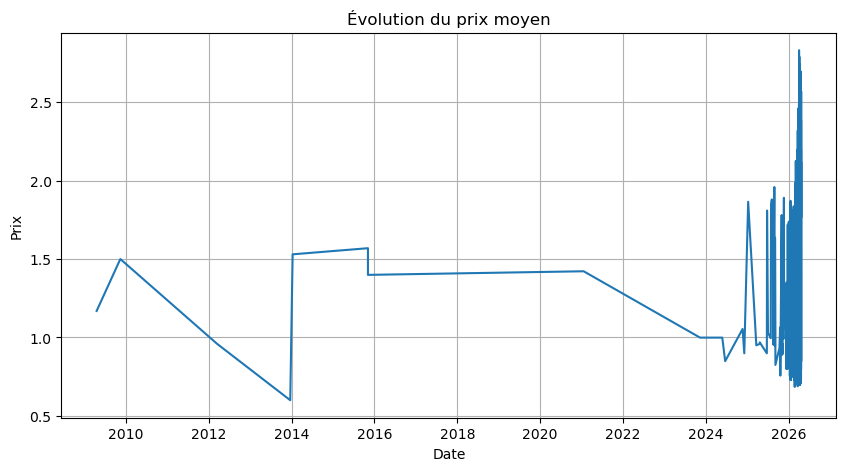

In [17]:
prix_journalier = data.groupby("date")["Prix"].mean()

plt.figure(figsize=(10,5))
plt.plot(prix_journalier)
plt.title("Évolution du prix moyen")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid()
plt.show()

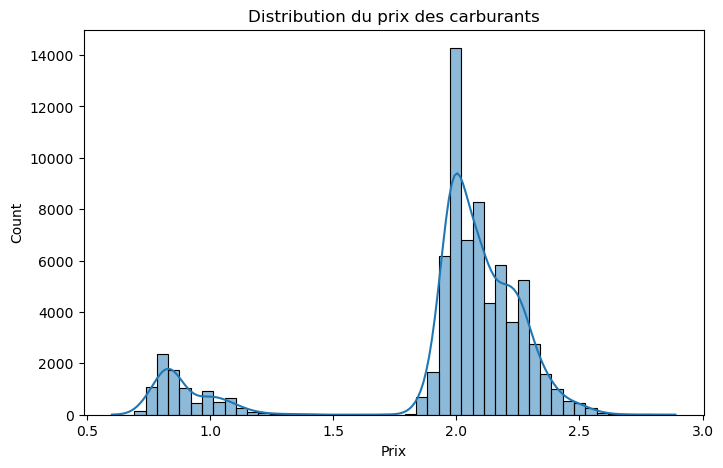

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data["Prix"], bins=50, kde=True)
plt.title("Distribution du prix des carburants")
plt.show()

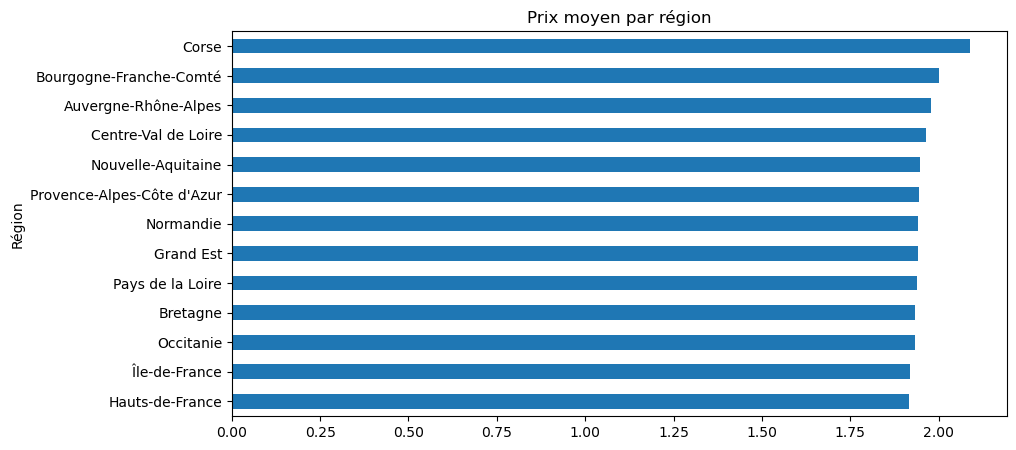

In [19]:
prix_region = data.groupby("Région")["Prix"].mean().sort_values()

prix_region.plot(kind="barh", figsize=(10,5))
plt.title("Prix moyen par région")
plt.show()

In [20]:
Nombre_station = data[['id']].nunique()
[Nombre_station]

[id    9896
 dtype: int64]

#### <span style="color: darkblue;"> 🔹 5) Filtrer un carburant (ex : Diesel) </span>

In [21]:
data["Carburant"].unique()

array(['E10', 'Gazole', 'SP98', 'E85', 'SP95', 'GPLc'], dtype=object)

In [22]:
data_diesel = data[data["Carburant"] == "Gazole"]

#### <span style="color: darkblue;"> 🔹 6) Analyse exploratoire (EDA)  </span>

##### <span style="color: darkblue;"> 📊 Évolution des prix dans le temps </span>

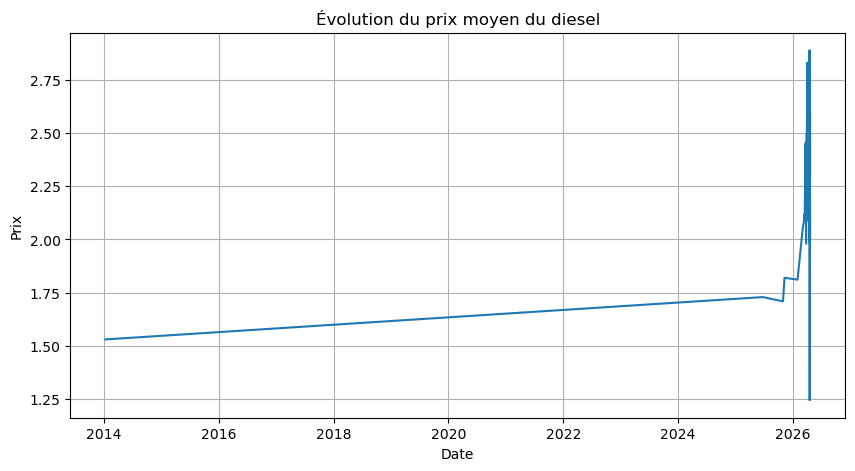

In [23]:
prix_journalier = data_diesel.groupby("date")["Prix"].mean()

plt.figure(figsize=(10,5))
plt.plot(prix_journalier)
plt.title("Évolution du prix moyen du diesel")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid()
plt.show()

##### <span style="color: darkblue;"> 📊  Distribution des prix </span>

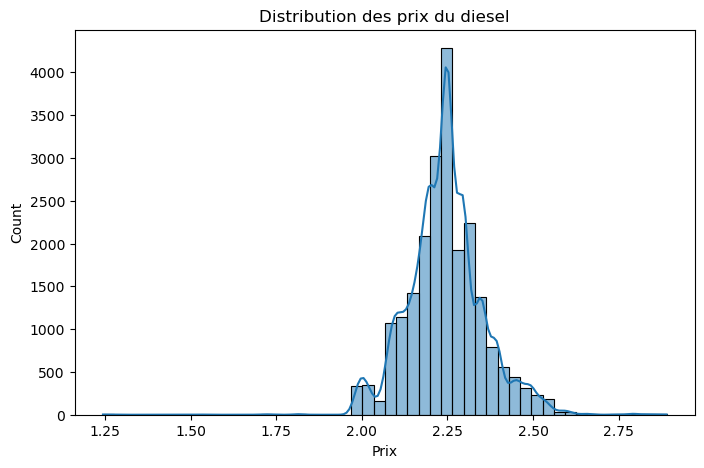

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data_diesel["Prix"], bins=50, kde=True)
plt.title("Distribution des prix du diesel")
plt.show()

##### <span style="color: darkblue;"> 📊 Prix par région </span>

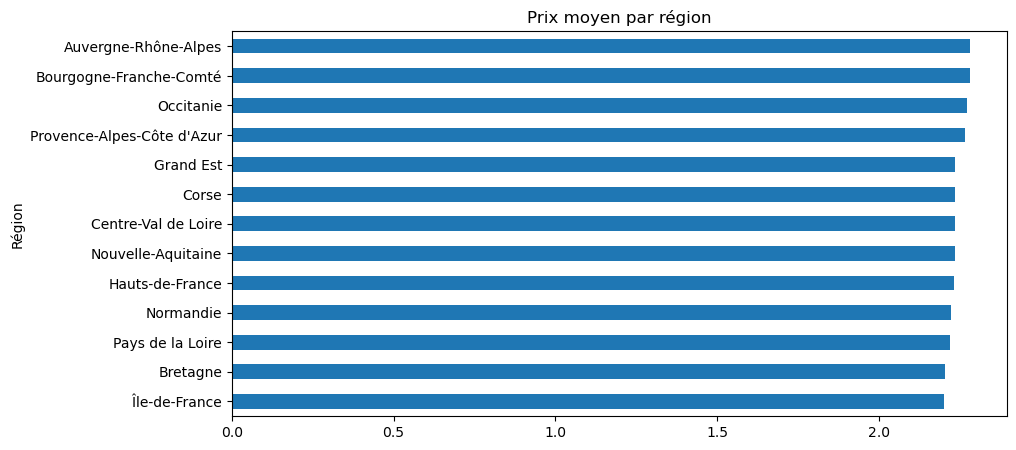

In [25]:
prix_region = data_diesel.groupby("Région")["Prix"].mean().sort_values()

prix_region.plot(kind="barh", figsize=(10,5))
plt.title("Prix moyen par région")
plt.show()

#### <span style="color: darkblue;"> 🔹 7) Feature Engineering  </span>

In [26]:
data_diesel["jour_semaine"] = data_diesel["date"].dt.dayofweek # extraire les jours de la semaine
data_diesel["mois"] = data_diesel["date"].dt.month # Extraire le mois 
data_diesel["jour"] = data_diesel["date"].dt.day # Extraire le jour

C:\Users\julem\AppData\Local\Temp\ipykernel_27052\2268842477.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_diesel["jour_semaine"] = data_diesel["date"].dt.dayofweek # extraire les jours de la semaine
C:\Users\julem\AppData\Local\Temp\ipykernel_27052\2268842477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_diesel["mois"] = data_diesel["date"].dt.month # Extraire le mois
C:\Users\julem\AppData\Local\Temp\ipykernel_27052\2268842477.py:3: SettingWithCopyWarning: 
A value is trying to be se

#### <span style="color: darkblue;"> 🔹 8) Analyse des variations  </span>

In [27]:
data_diesel = data_diesel.sort_values("date") # Tri du data Frame diesel en fonction de la date

data_diesel["variation_prix"] = data_diesel["Prix"].diff() # Variation des prix avec la fonction diff()

data_diesel[["date", "Prix", "variation_prix"]].head() # Affichage des 5 premières ligne du Data Frame 


,date,Prix,variation_prix
59452,2014-01-09 14:00:00+00:00,1.530,NaN
59453,2014-01-09 14:00:00+00:00,1.530,0.000
4199,2025-06-23 07:00:00+00:00,1.729,0.199
36414,2025-06-23 07:00:00+00:00,1.729,0.000
56847,2025-06-23 07:00:00+00:00,1.729,0.000


#### <span style="color: darkblue;"> 🔹 9) Détection des stations les moins chères </span>

In [28]:
stations_cheap = data_diesel.groupby(["id", "adresse_complete", "ville"])["Prix"].mean().sort_values().head(10)

stations_cheap

id        adresse_complete                       ville                
72000010  44 Rue de Bonnétable 72000             Le Mans                  1.244
99999001  rue victor hugo 99999                  Paris                    1.530
22700001  34 Rue Ernest Renan 22700              Perros-Guirec            1.709
57450001  37, GRAND RUE 57450                    Farébersviller           1.729
32500003  45, Avenue du Général De Gaulle 32500  Fleurance                1.811
20110005  4 QUARTIER ST JOSEPH 20110             Propriano                1.820
17138006  AIRE DE SERVICE - RN 11 17138          Puilboreau               1.972
44470006  RN 23 ROUTE DE PARIS 44470             Carquefou                1.976
44240011  BOULEVARD ALEXANDRE FLEMING 44240      La Chapelle-Sur-Erdre    1.977
27300006  RD 613 - CARREFOUR DE MALBROUCK 27300  Carsix                   1.979
Name: Prix, dtype: float64

In [29]:
data['id'].nunique()

9896

#### <span style="color: darkblue;"> 🔹 10) KPI  </span>

##### <span style="color: darkblue;"> 📊 Prix moyen par zone </span>

In [30]:
prix_moyen_region = data.groupby("Région")["Prix"].mean().sort_values()

prix_moyen_region

Région
Hauts-de-France               1.915418
Île-de-France                 1.918840
Occitanie                     1.934424
Bretagne                      1.934453
Pays de la Loire              1.939193
Grand Est                     1.941289
Normandie                     1.942071
Provence-Alpes-Côte d'Azur    1.945380
Nouvelle-Aquitaine            1.947383
Centre-Val de Loire           1.964265
Auvergne-Rhône-Alpes          1.979684
Bourgogne-Franche-Comté       2.002360
Corse                         2.088373
Name: Prix, dtype: float64

In [31]:
prix_moyen_dept = data.groupby("Département")["Prix"].mean().sort_values()
prix_moyen_dept

Département
Marne            1.860539
Haute-Garonne    1.863402
Essonne          1.882150
Val-d'Oise       1.885359
Nord             1.888965
                   ...   
Allier           2.024200
Cantal           2.051017
Paris            2.071566
Haute-Corse      2.085825
Corse-du-Sud     2.091486
Name: Prix, Length: 96, dtype: float64

##### <span style="color: darkblue;"> 📉 Volatilité des prix </span>

In [32]:
volatilite = data["Prix"].std()
volatilite

0.4280938029574967

In [33]:
# Volatilité des prix par région
volatilite_region = data.groupby("Région")["Prix"].std().sort_values(ascending=False)
volatilite_region

Région
Occitanie                     0.464453
Provence-Alpes-Côte d'Azur    0.455879
Hauts-de-France               0.447627
Auvergne-Rhône-Alpes          0.429594
Grand Est                     0.427746
Île-de-France                 0.424056
Nouvelle-Aquitaine            0.416071
Pays de la Loire              0.415269
Normandie                     0.412592
Bourgogne-Franche-Comté       0.408349
Centre-Val de Loire           0.408211
Bretagne                      0.395566
Corse                         0.196522
Name: Prix, dtype: float64

##### <span style="color: darkblue;"> 📈 Écart max / min </span>

In [34]:
# Global 

prix_max = data["Prix"].max()
prix_min = data["Prix"].min()
ecart = prix_max - prix_min

prix_max, prix_min, ecart

(2.89, 0.6, 2.29)

In [35]:
# Par Région 
ecart_region = data.groupby("Région")["Prix"].agg(lambda x: x.max() - x.min()).sort_values(ascending=False)
ecart_region

Région
Île-de-France                 2.190
Occitanie                     2.148
Pays de la Loire              2.133
Provence-Alpes-Côte d'Azur    2.092
Nouvelle-Aquitaine            2.077
Grand Est                     2.010
Bretagne                      1.967
Bourgogne-Franche-Comté       1.922
Hauts-de-France               1.889
Auvergne-Rhône-Alpes          1.877
Centre-Val de Loire           1.871
Normandie                     1.843
Corse                         1.099
Name: Prix, dtype: float64

##### <span style="color: darkblue;"> 🔄 Fréquence de mise à jour des prix </span>

In [36]:
# Ecarts entre mises à jour

data = data.sort_values(["id", "Carburant", "date"])

data["delta_update"] = data.groupby(["id", "Carburant"])["date"].diff()

In [37]:
data["delta_update"] 

34992      NaT
9882       NaT
13918      NaT
36313      NaT
34993      NaT
         ...  
12346   0 days
59452      NaT
59453   0 days
12347      NaT
73172   0 days
Name: delta_update, Length: 73184, dtype: timedelta64[ns]

In [38]:
# fréquence moyenne 
frequence_update = data['delta_update'].mean()
frequence_update

Timedelta('0 days 01:13:11.424282148')

In [39]:
# fréquence par station
frequence_par_station = data.groupby('id')['delta_update'].mean()
frequence_par_station

id
1000001       NaT
1000002    0 days
1000004    0 days
1000007    0 days
1000008    0 days
            ...  
95800003      NaT
95800007      NaT
95870009   0 days
95870010   0 days
99999001   0 days
Name: delta_update, Length: 9896, dtype: timedelta64[ns]

##  <span style="color: darkblue;"> 📓 B). Smart Fuel – Prédiction des prix du carburant </span>

###  <span style="color: darkblue;"> 🎯 Objectif </span>

Prédire le prix du carburant en fonction du temps et de certaines variables

Ici je filtre dans un premier temps sur le diesel


#### <span style="color: darkblue;">  🔹 1) Préparation des données </span>

In [40]:
# Ajout d'un features

data_diesel = data_diesel.sort_values(["id", "date"])

data_diesel["prix_jour_avant"] = data_diesel.groupby("id")["Prix"].shift(1)

In [41]:
# Suppression des NaN générés :

data_diesel = data_diesel.dropna()

In [42]:
data_diesel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12516 entries, 27907 to 59453
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   id                                  12516 non-null  int64              
 1   Code postal                         12516 non-null  int64              
 2   pop                                 12516 non-null  object             
 3   adresse                             12516 non-null  object             
 4   ville                               12516 non-null  object             
 5   horaires                            12516 non-null  object             
 6   rupture                             12516 non-null  object             
 7   fermeture                           12516 non-null  object             
 8   geom                                12516 non-null  object             
 9   Mise à jour des prix                1251

#### <span style="color: darkblue;">  🔹 2) Sélection des variables </span>

In [43]:
features = [
    "jour_semaine",
    "mois",
    "jour",
    "prix_jour_avant"
]

X = data_diesel[features]
y = data_diesel["Prix"]

#### <span style="color: darkblue;">  🔹 3) Train / Test split </span>

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### <span style="color: darkblue;">  🔹 4) Construction du modèle </span>

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
# 3.3 Coefficients du modèle
df_coeffs = pd.DataFrame({
    'Variables': X.columns,
    'Coefficients': model.coef_
})
print("\nCoefficients du modèle:\n")
print(df_coeffs.sort_values(by='Coefficients', key=abs, ascending=False))



Coefficients du modèle:

         Variables  Coefficients
3  prix_jour_avant      0.978377
1             mois     -0.002123
0     jour_semaine     -0.000730
2             jour     -0.000299


les features qui expliquent le mieux la régréssion linéaire est la variable **<span style="color: blue;"> prix_jour_avant </span>**

#### <span style="color: darkblue;">  🔹 5) Prédictions </span>

In [47]:
y_pred = model.predict(X_test)

#### <span style="color: darkblue;">  🔹 6) Évaluation du Modèle </span>

In [48]:
# Métriques d'évaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R² : {r2:.4f}")
print(f"MSE : {mse:.4f}")

R² : 0.9770
MSE : 0.0003


**<span style="color: blue;"> R² : 97,70%  </span>** indique que notre modèle prédit à **97,70** le prix des carburants (sans doute due au **au prix du jour avant**

**<span style="color: blue;"> MSE : 0.0003  </span>** montre que l'écart qudratique moyenne est très faible

#### <span style="color: darkblue;">  🔹 7) Visualisation résultats </span>


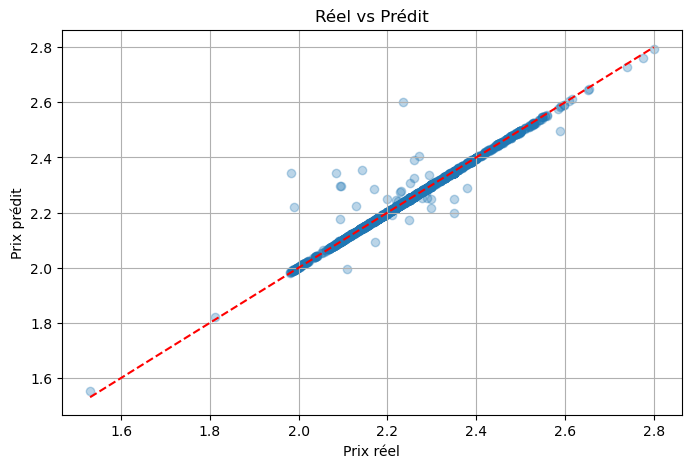

In [49]:
# Scatter plot Réel vs predit
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Réel vs Prédit")
plt.grid()
plt.show()

#### <span style="color: darkblue;">  🔹 8) Random Forest </span>

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#### <span style="color: darkblue;">  📏 Évaluation Random Forest </span>

In [51]:
# les métriques 
r2 = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)


r2, mse_rf

(0.9714587611084697, 0.00034409884170259243)

**<span style="color: blue;">Le Random Forest </span>** estime bien le prix des carburants avec un **<span style="color: blue;"> R² </span>** élevé et une **<span style="color: blue;"> MSE  </span>** trés faibles

#### <span style="color: darkblue;">  🔹 9)  Importance des variables </span>

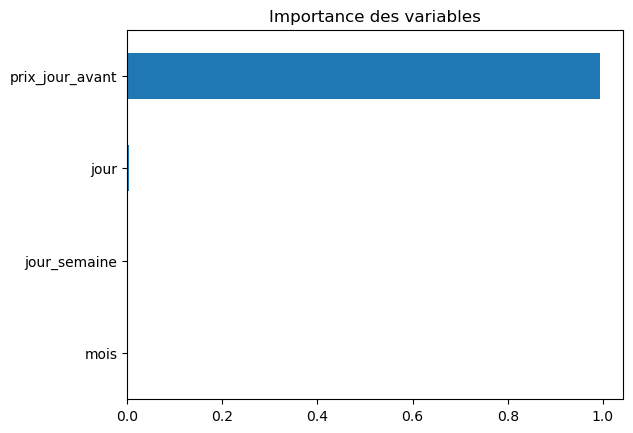

In [52]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values()

importance.plot(kind='barh', title="Importance des variables")
plt.show()

Ce graphique nous montre bien l'importance de la variable **<span style="color: blue;"> prix_jour_avant </span>** dans l'estimtion du prix des carburants.

##  <span style="color: darkblue;"> 📓 C). Smart Fuel – Système de recommandation </span> 

###  <span style="color: darkblue;"> 🚀 Objectif </span>

Recommander les stations les moins chères autour d’un utilisateur

#### <span style="color: darkblue;"> 🧱 Étape 1 : Préparation des données </span> 

##### <span style="color: darkblue;"> 📍 Extraction de  latitude / longitude depuis la colonne geom </span>

In [53]:
 data["geom"] = data["geom"].str.strip()
 data["geom"] =  data["geom"].astype(str)

In [54]:
data[["Latitude", "Longitude"]] = data["geom"].str.split(",", expand=True)

In [55]:
data["Latitude"] = data["Latitude"].astype(float)
data["Longitude"] = data["Longitude"].astype(float)

In [56]:
data[["geom", "Latitude", "Longitude"]].head()

,geom,Latitude,Longitude
34992,"46.201, 5.198",46.201,5.198
9882,"46.201, 5.198",46.201,5.198
13918,"46.201, 5.198",46.201,5.198
36313,"46.201, 5.198",46.201,5.198
34993,"46.201, 5.198",46.201,5.198


##### <span style="color: darkblue;"> 🧹 Nettoyage </span>

In [57]:
data_reco = data.copy()
data_reco = data.dropna(subset=["Latitude", "Longitude", "Prix"])

In [58]:
data_reco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73184 entries, 34992 to 73172
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   id                                  73184 non-null  int64              
 1   Code postal                         73184 non-null  int64              
 2   pop                                 73184 non-null  object             
 3   adresse                             73184 non-null  object             
 4   ville                               73184 non-null  object             
 5   horaires                            73184 non-null  object             
 6   rupture                             73184 non-null  object             
 7   fermeture                           72509 non-null  object             
 8   geom                                73184 non-null  object             
 9   Mise à jour des prix                7318

##### <span style="color: darkblue;"> ⛽ Filtre sur un carburant </span>

In [59]:
# data_reco_diesel = data_reco[data_reco["Carburant"] == "Gazole"]

In [60]:
# Ajout des colonnes latitude et longitude dans les données diesels
data_diesel[["Latitude", "Longitude"]] = data_diesel["geom"].str.split(",", expand=True)
# Conversion en float
data_diesel["Latitude"] = data_diesel["Latitude"].astype(float)
data_diesel["Longitude"] = data_diesel["Longitude"].astype(float)
# Vérification 
data_diesel[["geom", "Latitude", "Longitude"]].head()

,geom,Latitude,Longitude
27907,"46.21842, 5.22767",46.21842,5.22767
25966,"46.21842, 5.22767",46.21842,5.22767
71820,"46.188, 5.245",46.18800,5.24500
59547,"46.221, 5.245",46.22100,5.24500
23878,"46.199, 5.241",46.19900,5.24100


In [61]:
data_reco_diesel = data_diesel.copy()

#### <span style="color: darkblue;"> 📍 Étape 2 : Localisation utilisateur </span> 

In [62]:
# Par exemple si nous prénons un utilisateur avec les coordonnées suivantes 
user_lat = 48.85
user_lon = 2.35

#### <span style="color: darkblue;"> 📏 Étape 3 : Calcul de distance (formule haversine) </span> 

#### **haversine_distances**

sklearn.metrics.pairwise.haversine_distances(X, Y=Aucun)

Calculez la distance de Haversine entre les échantillons de X et Y.

La distance haversienne (ou grand cercle) est la distance angulaire entre deux points à la surface d’une sphère.

La première coordonnée de chaque point est supposée être la latitude, 

la seconde est la longitude, étant donné en radians. La dimension des données doit être 2.

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>D</mi>
  <mo stretchy="false">(</mo>
  <mi>x</mi>
  <mo>,</mo>
  <mi>y</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <mn>2</mn>
  <mi>arcsin</mi>
  <mo data-mjx-texclass="NONE">&#x2061;</mo>
  <mo stretchy="false">[</mo>
  <msqrt>
    <msup>
      <mi>sin</mi>
      <mn>2</mn>
    </msup>
    <mo data-mjx-texclass="NONE">&#x2061;</mo>
    <mo stretchy="false">(</mo>
    <mo stretchy="false">(</mo>
    <msub>
      <mi>x</mi>
      <mrow data-mjx-texclass="ORD">
        <mi>l</mi>
        <mi>a</mi>
        <mi>t</mi>
      </mrow>
    </msub>
    <mo>&#x2212;</mo>
    <msub>
      <mi>y</mi>
      <mrow data-mjx-texclass="ORD">
        <mi>l</mi>
        <mi>a</mi>
        <mi>t</mi>
      </mrow>
    </msub>
    <mo stretchy="false">)</mo>
    <mrow data-mjx-texclass="ORD">
      <mo>/</mo>
    </mrow>
    <mn>2</mn>
    <mo stretchy="false">)</mo>
    <mo>+</mo>
    <mi>cos</mi>
    <mo data-mjx-texclass="NONE">&#x2061;</mo>
    <mo stretchy="false">(</mo>
    <msub>
      <mi>x</mi>
      <mrow data-mjx-texclass="ORD">
        <mi>l</mi>
        <mi>a</mi>
        <mi>t</mi>
      </mrow>
    </msub>
    <mo stretchy="false">)</mo>
    <mi>cos</mi>
    <mo data-mjx-texclass="NONE">&#x2061;</mo>
    <mo stretchy="false">(</mo>
    <msub>
      <mi>y</mi>
      <mrow data-mjx-texclass="ORD">
        <mi>l</mi>
        <mi>a</mi>
        <mi>t</mi>
      </mrow>
    </msub>
    <mo stretchy="false">)</mo>
    <mtext>&#xA0;</mtext>
    <mi>s</mi>
    <mi>i</mi>
    <msup>
      <mi>n</mi>
      <mn>2</mn>
    </msup>
    <mo stretchy="false">(</mo>
    <mo stretchy="false">(</mo>
    <msub>
      <mi>x</mi>
      <mrow data-mjx-texclass="ORD">
        <mi>l</mi>
        <mi>o</mi>
        <mi>n</mi>
      </mrow>
    </msub>
    <mo>&#x2212;</mo>
    <msub>
      <mi>y</mi>
      <mrow data-mjx-texclass="ORD">
        <mi>l</mi>
        <mi>o</mi>
        <mi>n</mi>
      </mrow>
    </msub>
    <mo stretchy="false">)</mo>
    <mrow data-mjx-texclass="ORD">
      <mo>/</mo>
    </mrow>
    <mn>2</mn>
    <mo stretchy="false">)</mo>
  </msqrt>
  <mo stretchy="false">]</mo>
</math>

In [63]:
# Création de la fonction haversine() pour calculer la distance entre deux points 

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # rayon Terre km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

##### <span style="color: darkblue;"> 📍 Application pour le Calcul de la distance </span>

In [64]:
# Calcul de la distance en km 
data_reco_diesel["distance_km"] = data_reco_diesel.apply(
    lambda row: haversine(user_lat, user_lon, row["Latitude"], row["Longitude"]),
    axis=1
)

#### <span style="color: darkblue;"> 🎯 Étape 4 : Filtre sur les Stations les plus proches </span> 

In [65]:
rayon = 10  # km

stations_proches = data_reco_diesel[data_reco_diesel["distance_km"] <= rayon]

In [66]:
stations_proches[["id", "adresse_complete", "ville", "Prix", "distance_km"]].head()

,id,adresse_complete,ville,Prix,distance_km
19764,75001003,"8,10,10bis Rue Bailleul 75001",Paris,2.89,1.389117
46148,75001003,"8,10,10bis Rue Bailleul 75001",Paris,2.89,1.389117
34893,75007003,15 Avenue Duquesne 75007,Paris,2.80,3.091096
43729,75007003,15 Avenue Duquesne 75007,Paris,2.80,3.091096
3034,75007003,15 Avenue Duquesne 75007,Paris,2.80,3.091096


In [67]:
data_reco_diesel["distance_km"]

27907    363.667599
25966    363.667599
71820    367.198755
59547    364.207775
23878    366.022371
            ...    
24171     24.558509
50172     14.114375
58942     14.114375
50839     14.235954
59453    379.355325
Name: distance_km, Length: 12516, dtype: float64

#### <span style="color: darkblue;"> 💰 Étape 5 : Trouver les stations les moins chères </span> 

In [68]:
stations_reco = stations_proches.sort_values('Prix').head(10)

stations_reco[["id", "adresse_complete", "ville", "Prix", "distance_km"]]

,id,adresse_complete,ville,Prix,distance_km
15333,93120005,AUTOROUTE A1 - AIRE DE LA COURNEUVE OUEST - SE...,La Courneuve,2.012,9.983966
41174,75016011,69 Avenue Kléber 75116,Paris,2.019,4.764201
39717,93000010,54 AVENUE LOUIS ARAGON 93000,Bobigny,2.036,9.742824
47909,93000010,54 AVENUE LOUIS ARAGON 93000,Bobigny,2.036,9.742824
36757,94800007,117 BLD MAXIME GORKI 94800,Villejuif,2.038,6.505046
43049,94800008,60 AV DE STALINGRAD 94800,Villejuif,2.038,7.283361
36745,94400005,34 AV. HENRI BARBUSSE 94400,Vitry-Sur-Seine,2.040,6.981943
9991,93100014,48-54 BOULEVARD THEOPHILE SUEUR 93100,Montreuil,2.041,9.064630
59939,94000009,63 Avenue du Général de Gaulle 94000,Créteil,2.041,9.617199
3133,94000009,63 Avenue du Général de Gaulle 94000,Créteil,2.041,9.617199


#### <span style="color: darkblue;"> 🧠 Étape 6 : Version  (score) </span> 

In [69]:
# On combine prix + distance
# Création d'une variable score avec 70% du Prix plus 30% de la distance 

stations_proches["score"] = (
    stations_proches["Prix"] * 0.7 +
    stations_proches["distance_km"] * 0.3
)

recommandations = stations_proches.sort_values("score").head(10)

C:\Users\julem\AppData\Local\Temp\ipykernel_27052\2999890158.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stations_proches["score"] = (


In [70]:
recommandations[["id", "adresse_complete", "ville", "Prix", "distance_km", "score"]]

,id,adresse_complete,ville,Prix,distance_km,score
46151,75013024,114 BD DE L HOPITAL 75013,Paris,2.153,1.767687,2.037406
47845,75013025,"181, BOULEVARD VINCENT AURIOL 75013",Paris,2.043,2.107096,2.062229
64268,75012010,36 Quai de la Rapée 75012,Paris,2.315,1.903666,2.191600
69691,75012010,36 Quai de la Rapée 75012,Paris,2.315,1.903666,2.191600
70180,75014010,RUE LEGION ETRANGERE 75014,Paris,2.167,2.921945,2.393483
61918,75014010,RUE LEGION ETRANGERE 75014,Paris,2.168,2.921945,2.394183
4470,75007004,37 RUE FABERT 75007,Paris,2.159,2.992733,2.409120
47841,75007004,37 RUE FABERT 75007,Paris,2.159,2.992733,2.409120
53130,75013026,231 Rue de Tolbiac 75013,Paris,2.319,2.704565,2.434670
4479,75013026,231 Rue de Tolbiac 75013,Paris,2.319,2.704565,2.434670


#### <span style="color: darkblue;"> Intégration dans le modèle de Machine Learning </span> 

In [71]:
# Prédiction du Prix future 
stations_proches["prix_predit"] = rf.predict(stations_proches[features])

C:\Users\julem\AppData\Local\Temp\ipykernel_27052\3430612875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stations_proches["prix_predit"] = rf.predict(stations_proches[features])


In [72]:
stations_proches["prix_predit"]

19764    2.880660
46148    2.880660
34893    2.799410
43729    2.799410
3034     2.799410
           ...   
2508     2.132500
35490    2.398980
58929    2.175134
36757    2.037940
43049    2.037940
Name: prix_predit, Length: 163, dtype: float64

In [73]:
# On combine prix + distance et le prix prédit 
# Création d'une variable score avec 40% du Prix et 40% du prix prédit  plus 20% de la distance 

stations_proches["score"] = (
    stations_proches["Prix"] * 0.4 +
    stations_proches["prix_predit"] * 0.4 +
    stations_proches["distance_km"] * 0.2
)

recommandations = stations_proches.sort_values("score").head(10)

C:\Users\julem\AppData\Local\Temp\ipykernel_27052\2597950521.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stations_proches["score"] = (


In [74]:
recommandations[["id", "adresse_complete", "ville", "Prix", "prix_predit", "distance_km", "score"]]

,id,adresse_complete,ville,Prix,prix_predit,distance_km,score
47845,75013025,"181, BOULEVARD VINCENT AURIOL 75013",Paris,2.043,2.043000,2.107096,2.055819
46151,75013024,114 BD DE L HOPITAL 75013,Paris,2.153,2.153000,1.767687,2.075937
69691,75012010,36 Quai de la Rapée 75012,Paris,2.315,2.315000,1.903666,2.232733
64268,75012010,36 Quai de la Rapée 75012,Paris,2.315,2.315000,1.903666,2.232733
70180,75014010,RUE LEGION ETRANGERE 75014,Paris,2.167,2.167837,2.921945,2.318324
4470,75007004,37 RUE FABERT 75007,Paris,2.159,2.151508,2.992733,2.322750
47841,75007004,37 RUE FABERT 75007,Paris,2.159,2.151508,2.992733,2.322750
61918,75014010,RUE LEGION ETRANGERE 75014,Paris,2.168,2.223400,2.921945,2.340949
30496,75012020,238 RUE DE CHARENTON 75012,Paris,2.153,2.153000,3.106856,2.343771
5386,75012020,238 RUE DE CHARENTON 75012,Paris,2.153,2.153000,3.106856,2.343771
